In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install optuna

## Imports

In [3]:
# Imports
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import cv2 as cv
import pandas as pd
import os
from tqdm import tqdm
from sklearn.model_selection import train_test_split
import logging
from time import time
from sklearn.metrics import f1_score
import optuna

## Configs

In [4]:
# Configs
seed = 17
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [5]:
# Configs
BASE = "/kaggle/input/datasets/scolianni/mnistasjpg/trainingSet/trainingSet"
classes = sorted(os.listdir(BASE))
# class to idx
clsToIdx = {cls: idx for idx, cls in enumerate(classes)}
# idx to class
IdxToCls = {idx: cls for idx, cls in enumerate(classes)}

In [6]:
# logging Configs
logger = logging.getLogger("MNIST_ANN")
logging.basicConfig(filename='example.log', encoding='utf-8', level=logging.INFO, format='%(asctime)s %(levelname)s %(message)s', force=True)
logger.info('So should this')

## EDA

<class 'numpy.ndarray'>
(28, 28, 3)


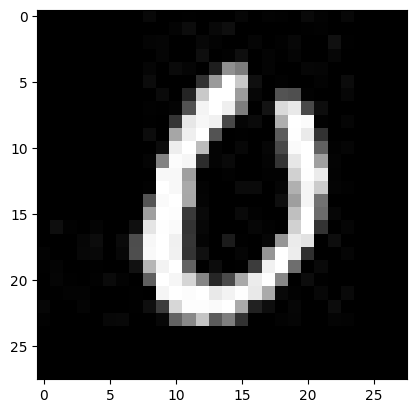

In [7]:
# EDA
img = cv.imread("/kaggle/input/datasets/scolianni/mnistasjpg/trainingSet/trainingSet/0/img_10007.jpg")
plt.imshow(img)
print(type(img))
print(img.shape)

(28, 28)


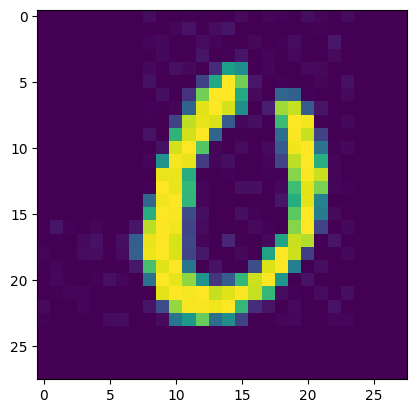

In [8]:
# converting a image from 3 channels to 1 channel using gray scale (0-255)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
plt.imshow(gray)
print(gray.shape)

## Dataset Creation

In [9]:
# Dataframe
Xts = []   # trainingSet - features
yts = []   # trainingSet - result
for dn in sorted(os.listdir(BASE)):
    dig_path = os.path.join(BASE, dn)
    for img in tqdm(os.listdir(dig_path), desc=dn):
        img_path = os.path.join(dig_path, img)
        
        if os.path.isfile(img_path):

            Xts.append(img_path)
            yts.append(clsToIdx[dn])

9: 100%|██████████| 4188/4188 [00:16<00:00, 258.14it/s]


In [10]:
# train val split
X_train, X_val, y_train, y_val = train_test_split(Xts, yts, test_size=0.20, shuffle=True, random_state=seed, stratify=yts)

### Important datatypes
```
In PyTorch, everything is built around torch.Tensor. Model and loss functions only operate on tensors. If you skip this, things either break or become inefficient.


CrossEntropyLoss
    Requirements:
    output → float tensor
    target → long tensor (class indices)


loss.backward()
    Works only if:
    
    inputs are tensors
    operations are tracked


img = img.to("cuda")

    Only tensors can go to GPU.
```

In [11]:
def preProcessing(img_path):
    """function that does full preprocessing on train and test dataset."""
    img = cv.imread(img_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    img = torch.tensor(img, dtype=torch.float32)
    img = img/255.0
    
    return img

    

In [12]:
# Dataset and Dataloader
class MnistDataset(Dataset):
    """Custom class for creating dataset, named MnistDataset."""
    def __init__(self, X, y=None):
        super().__init__()
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y != None:   # for train and val data
            img_path = self.X[idx]
            label = self.y[idx]

            img = preProcessing(img_path)
            label = torch.tensor(label, dtype=torch.long)   # Loss like CrossEntropyLoss expects integer class indices

            return img, label   # (28, 28) tensor, scaler tensor
        else:   # for test data
            img_path = self.X[idx]
            img = preProcessing(img_path)
            return img, os.path.basename(img_path)

In [13]:
# datasets
train_dataset = MnistDataset(X_train, y_train)
val_dataset = MnistDataset(X_val, y_val)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=62, shuffle=True, num_workers=2)   # shuffles after every epoch and re-devides into batches
val_loader = DataLoader(val_dataset, batch_size=62, shuffle=False, num_workers=2)

## Model Creation

In [14]:
# model creation
class MnistANN(nn.Module):
    """class for creating custom ANN model, named MnistANN."""
    def __init__(self, nc):
        super().__init__()

        self.features = nn.Sequential(
            nn.Linear(28*28, 128, bias=True),
            nn.ReLU(),          
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, nc, bias=True)
        )

        self.flatten = nn.Flatten()

    def forward(self, x):   # (B, 28, 28)
        x = self.flatten(x)   # (B, 28*28)
        x = self.features(x)   # (B, 128)
        return self.classifier(x)   # (B, 10)

In [15]:
# model
model = MnistANN(10)
model.to(DEVICE)

# criterion
criterion = nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.002398358870389639)

## Training and Validation

In [16]:
# Train and Validation

def trainOneEpoch(loader, model, criterion, optimizer, DEVICE):
    """This function trains a model for one epoch."""
    model.train()
    total_loss = 0

    y_pred = []
    y_true = []
    for x, y in tqdm(loader, desc="train"):
        x, y = x.to(DEVICE), y.to(DEVICE)
        
        model.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        # loss
        total_loss += loss.item()

        # performance
        p = torch.argmax(out.detach(), dim=1).cpu().tolist()
        y_pred.extend(p)
        y_true.extend(y.cpu().tolist())

    macro_f1 = f1_score(y_true, y_pred, average='macro')
    # print(macro_f1)
    

    return total_loss, macro_f1

# validation
def valOneEpoch(loader, model, criterion, DEVICE):
    """This function checks the performance of a model after one epoch."""
    model.eval()
    total_loss = 0

    y_pred = []
    y_true = []
    with torch.no_grad():
        for x, y in tqdm(loader, desc="val"):
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)

            loss = criterion(out, y)
    
            total_loss += loss.item()

            # performance
            p = torch.argmax(out.detach(), dim=1).cpu().tolist()
            y_pred.extend(p)
            y_true.extend(y.cpu().tolist())
    
        macro_f1 = f1_score(y_true, y_pred, average='macro')
        # print(macro_f1)

    return total_loss, macro_f1

# trainOneEpoch(train_loader, model)

In [17]:
def training(EPOCHS, train_loader, val_loader, model, criterion, optimizer, DEVICE):
    """This function is main training function which trains and validates a model on several epochs."""
    t_loss_list = []
    v_loss_list = []

    t_macrof1 = []
    v_macrof1 = []
    for epoch in range(EPOCHS):
        
        start = time()
        t_loss, tmf1 = trainOneEpoch(train_loader, model, criterion, optimizer, DEVICE)
        v_loss, vmf1 = valOneEpoch(val_loader, model, criterion, DEVICE)
    
        t_loss_list.append(t_loss)
        v_loss_list.append(v_loss)

        t_macrof1.append(tmf1)
        v_macrof1.append(vmf1)
    
        print(f"EPOCH: {epoch+1} | Train Loss: {t_loss} | Val Loss: {v_loss}")
        print(round(time() - start))
        
    return t_loss_list, v_loss_list, t_macrof1, v_macrof1

EPOCHS = 5
t_loss_list, v_loss_list, t_macrof1, v_macrof1 = training(EPOCHS, train_loader, val_loader, model, criterion, optimizer, DEVICE)

val: 100%|██████████| 136/136 [00:43<00:00,  3.11it/s]


EPOCH: 1 | Train Loss: 183.5745489411056 | Val Loss: 23.13226617127657
213


val: 100%|██████████| 136/136 [00:10<00:00, 12.98it/s]


EPOCH: 2 | Train Loss: 81.83580005727708 | Val Loss: 17.710369491949677
55


val: 100%|██████████| 136/136 [00:12<00:00, 10.84it/s]


EPOCH: 3 | Train Loss: 55.17211442068219 | Val Loss: 15.198154926300049
59


val: 100%|██████████| 136/136 [00:15<00:00,  8.70it/s]


EPOCH: 4 | Train Loss: 40.32900740718469 | Val Loss: 13.460710693150759
74


val: 100%|██████████| 136/136 [00:10<00:00, 12.65it/s]

EPOCH: 5 | Train Loss: 28.970373468473554 | Val Loss: 13.028744945768267
54


## Hyperparameter Tuning

In [ ]:
# # first I will be tuning - batch size and learning rate

# # Define the objective function
# def objective(trial):
#     # Suggest values for the hyperparameters
#     batch_size = trial.suggest_int('batch_size', 10, 80)
#     lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)

#     # param initialization
#     EPOCHS = 5
#     DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

#     # model
#     model = MnistANN(10)
#     model.to(DEVICE)
#     # criterion
#     criterion = nn.CrossEntropyLoss()
#     # optimizer
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)

#     # datasets
#     train_dataset = MnistDataset(X_train, y_train)
#     val_dataset = MnistDataset(X_val, y_val)
    
#     # dataloaders
#     train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)   # shuffles after every epoch and re-devides into batches
#     val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

#     # training
#     t_loss_list, v_loss_list, t_macrof1, v_macrof1 = training(EPOCHS, train_loader, val_loader, model, criterion, optimizer, DEVICE)

#     # returning metrics value
#     return v_macrof1[-1]   

In [ ]:
# # Create a study object and optimize the objective function
# study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())  # We aim to maximize accuracy
# study.optimize(objective, n_trials=50)  # Run 50 trials to find the best hyperparameters

In [ ]:
# # Print the best result
# print(f'Best trial accuracy: {study.best_trial.value}')
# print(f'Best hyperparameters: {study.best_trial.params}')

# # Best trial accuracy: 0.9732500376972931
# # Best hyperparameters: {'batch_size': 62, 'lr': 0.002398358870389639}

In [ ]:
# # For visualizations
# from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

In [ ]:
# # 1. Optimization History
# plot_optimization_history(study).show()

In [ ]:
# # 2. Parallel Coordinates Plot
# plot_parallel_coordinate(study).show()

In [ ]:
# # 3. Slice Plot
# plot_slice(study).show()

In [ ]:
# # 4. Contour Plot
# plot_contour(study).show()

In [ ]:
# # 5. Hyperparameter Importance
# plot_param_importances(study).show()

Text(0.5, 0, 'Epochs')

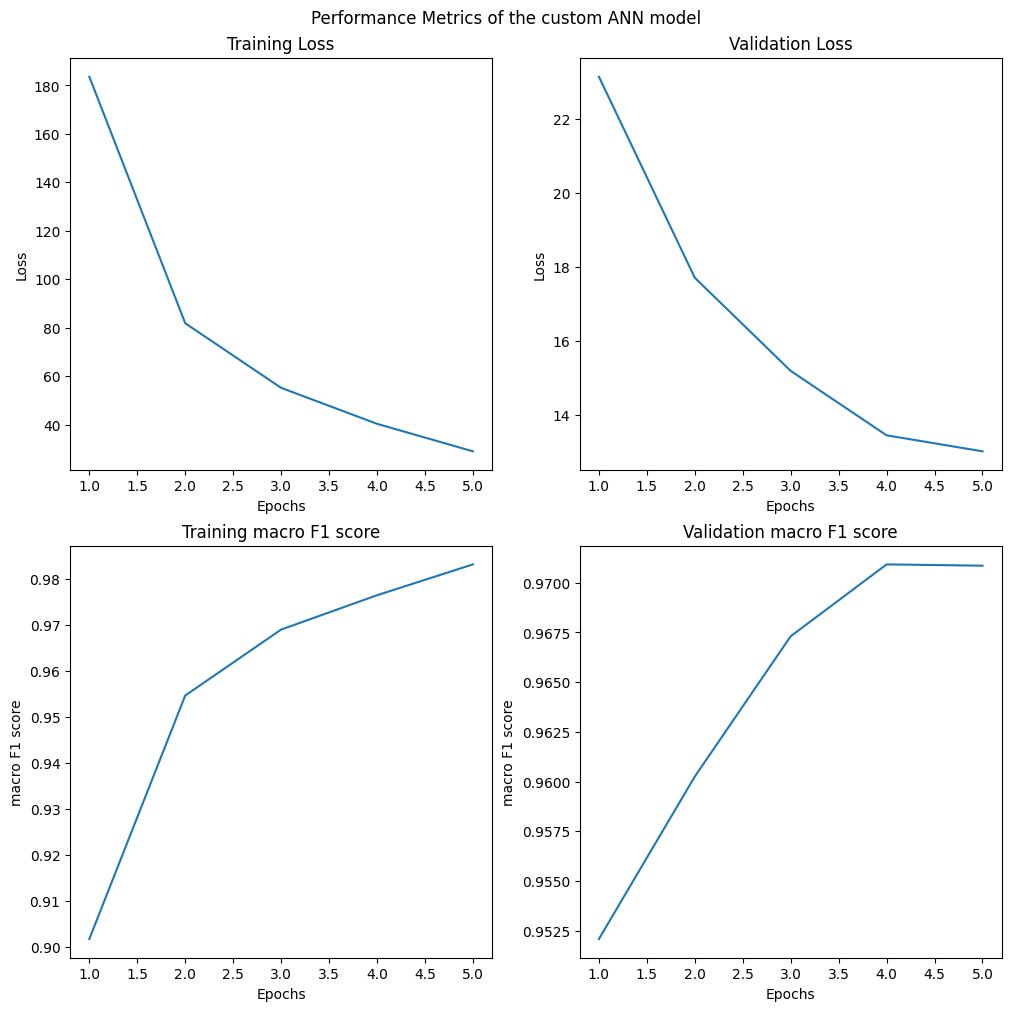

In [18]:
# Plotting the train and validation loss graphs

fig, axs = plt.subplots(2, 2, layout='constrained')
fig.set_figheight(10)
fig.set_figwidth(10)
fig.suptitle("Performance Metrics of the custom ANN model")

# Training Loss
ax = axs[0][0]
ax.plot(range(1, EPOCHS+1), t_loss_list)
ax.set_title("Training Loss")
ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")

# Validation Loss
ax = axs[0][1]
ax.plot(range(1, EPOCHS+1), v_loss_list)
ax.set_title("Validation Loss")
ax.set_ylabel("Loss")
ax.set_xlabel("Epochs")

# Training performance - macro f1
ax = axs[1][0]
ax.plot(range(1, EPOCHS+1), t_macrof1)
ax.set_title("Training macro F1 score")
ax.set_ylabel("macro F1 score")
ax.set_xlabel("Epochs")

# Validation performance - macro f1
ax = axs[1][1]
ax.plot(range(1, EPOCHS+1), v_macrof1)
ax.set_title("Validation macro F1 score")
ax.set_ylabel("macro F1 score")
ax.set_xlabel("Epochs")

## Model Testing

In [19]:
# Test
test_samples = [
    "/kaggle/input/datasets/scolianni/mnistasjpg/testSet/testSet/img_1.jpg",
    "/kaggle/input/datasets/scolianni/mnistasjpg/testSet/testSet/img_10.jpg",
    "/kaggle/input/datasets/scolianni/mnistasjpg/testSet/testSet/img_10001.jpg"
]

# dataset
test_dataset = MnistDataset(test_samples)

# dataloader
test_loader = DataLoader(test_dataset, batch_size=30, shuffle=False, num_workers=2)   # shuffles after every epoch and re-devides into batches

In [20]:
def testModel(loader, model):
    """This function tests the model on the test dataset."""
    model.eval()
    y_predIdx = []
    y_predImg = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="test"):
            x = x.to(DEVICE)
            out = model(x)

            idx = torch.argmax(out.detach(), dim=1).cpu().tolist()

            y_predIdx.extend(idx)
            y_predImg.extend(y)

    for i in range(len(y_predIdx)):
        
        label = IdxToCls[y_predIdx[i]]
        img = y_predImg[i]
        print(f"{img}: {label}")


testModel(test_loader, model)

test: 100%|██████████| 1/1 [00:00<00:00,  8.28it/s]

img_1.jpg: 2
img_10.jpg: 3
img_10001.jpg: 0
